In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn import svm
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold

In [3]:
df = pd.read_csv('Bank Customer Churn Prediction.csv')
df = df.drop('customer_id', axis=1)
df.head()

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
print(df.shape)
df.info()

(10000, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   credit_score      10000 non-null  int64  
 1   country           10000 non-null  object 
 2   gender            10000 non-null  object 
 3   age               10000 non-null  int64  
 4   tenure            10000 non-null  int64  
 5   balance           10000 non-null  float64
 6   products_number   10000 non-null  int64  
 7   credit_card       10000 non-null  int64  
 8   active_member     10000 non-null  int64  
 9   estimated_salary  10000 non-null  float64
 10  churn             10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


In [5]:
# Проверка на дубликаты
df.drop_duplicates(inplace=True)

In [6]:
# проверка наличия нулевых значений
df.isnull().sum()

credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

In [7]:
categorical_features = df[['country', 'gender']]
binary_feautures = df[['credit_card', 'active_member']]
numerical_features = df[['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary']]

In [8]:
numerical_features.describe()

,credit_score,age,tenure,balance,products_number,estimated_salary
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,100090.239881
std,96.653299,10.487806,2.892174,62397.405202,0.581654,57510.492818
min,350.000000,18.000000,0.000000,0.000000,1.000000,11.580000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,51002.110000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,100193.915000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,149388.247500
max,850.000000,92.000000,10.000000,250898.090000,4.000000,199992.480000


In [9]:
binary_feautures.describe()

,credit_card,active_member
count,10000.00000,10000.000000
mean,0.70550,0.515100
std,0.45584,0.499797
min,0.00000,0.000000
25%,0.00000,0.000000
50%,1.00000,1.000000
75%,1.00000,1.000000
max,1.00000,1.000000


In [10]:
categorical_features.describe()

,country,gender
count,10000,10000
unique,3,2
top,France,Male
freq,5014,5457


In [11]:
labelencoder = LabelEncoder()
df['country'] = labelencoder.fit_transform(df['country'])

onehotencoder = OneHotEncoder(sparse_output=False)
 
encoded_df_1 = pd.DataFrame(onehotencoder.fit_transform(df[['country']]))

onehotencoder.get_feature_names_out()
encoded_df_1.columns = onehotencoder.get_feature_names_out()
# объединяем данные к изначальным, удаляем столбец country
df = df.join(encoded_df_1)
df.drop('country', axis = 1, inplace = True)
df = df.rename(columns={"country_0": "France", "country_1": "Germany", "country_2": "Spain"})

In [12]:
labelencoder = LabelEncoder()
df['gender'] = labelencoder.fit_transform(df['gender'])
onehotencoder = OneHotEncoder(sparse_output=False)

encoded_df_2 = pd.DataFrame(onehotencoder.fit_transform(df[['gender']]))
onehotencoder.get_feature_names_out()
encoded_df_2.columns = onehotencoder.get_feature_names_out()

df.drop('gender', axis = 1, inplace = True)

df = df.join(encoded_df_2)
pd.get_dummies(['Female', 'Male'])
df = df.rename(columns={"gender_0": "Female", "gender_1": "Male"})
df.head()

,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,France,Germany,Spain,Female,Male
0,619,42,2,0.00,1,1,1,101348.88,1,1.0,0.0,0.0,1.0,0.0
1,608,41,1,83807.86,1,0,1,112542.58,0,0.0,0.0,1.0,1.0,0.0
2,502,42,8,159660.80,3,1,0,113931.57,1,1.0,0.0,0.0,1.0,0.0
3,699,39,1,0.00,2,0,0,93826.63,0,1.0,0.0,0.0,1.0,0.0
4,850,43,2,125510.82,1,1,1,79084.10,0,0.0,0.0,1.0,1.0,0.0


In [27]:
y = df['churn']
X = df.drop('churn', axis=1)

# Разбиение выборки на train и test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
def get_accuracy_and_error(y_test, y_pred):
    accuracy = accuracy_score(y_test, y_pred)
    error_rate = 1 - accuracy
    print(f'Accuracy: {round(accuracy * 100, 2)}%')
    print(f'Error rate: {round(error_rate * 100, 2)}%')

In [29]:
def get_confusion_matrix(y_test, y_pred):
    conf_matrix = confusion_matrix(y_test, y_pred)

    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Reds')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

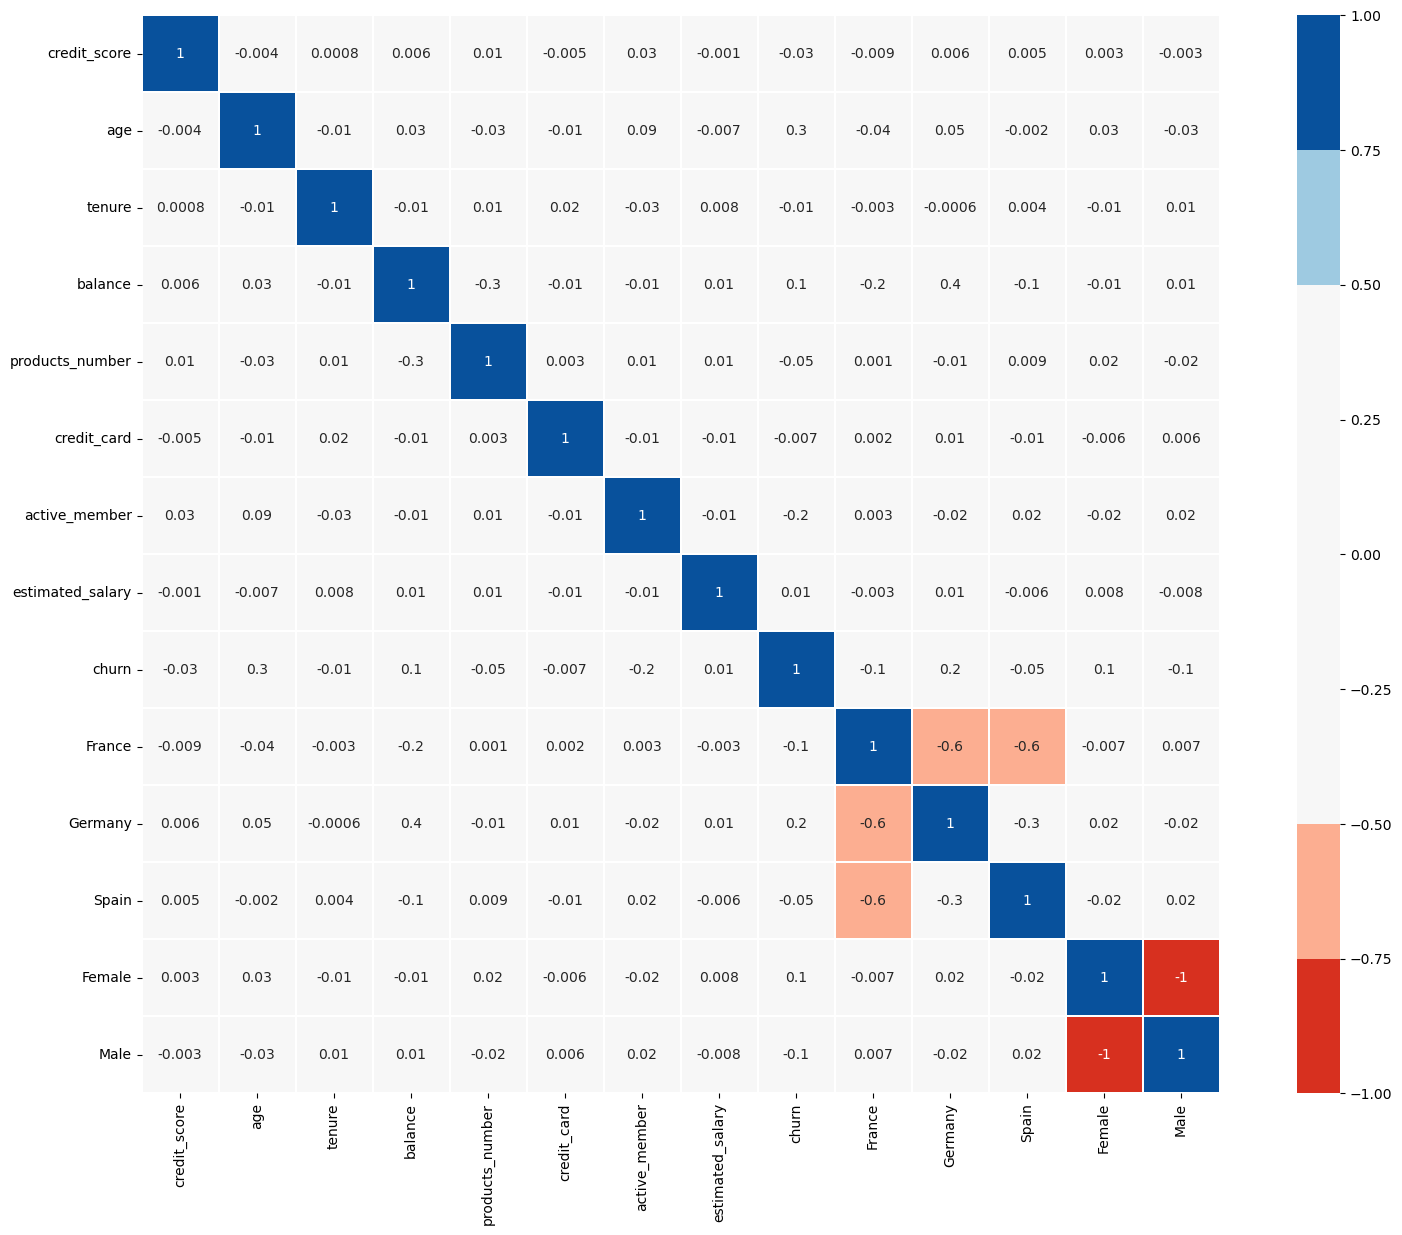

In [37]:
# Создание новой цветовой карты для подсвечивания сильных связей
color_map = sns.color_palette(['#d7301f', '#fcae91', '#f7f7f7', '#f7f7f7', '#f7f7f7', '#f7f7f7', '#9ecae1', '#08519c'])

# Определение размера диаграммы
plt.figure(figsize=(20, 14))

# Вывод корреляционной матрицы
ax = sns.heatmap(df.corr(), cmap=color_map, square=True, vmin=-1, vmax=1, center= 0, linewidths=0.1, linecolor='white', annot=True, fmt='.1g', cbar_kws=dict(ticks=np.arange(-1.0, 1.1, 0.25), aspect=25))

# Вывод диаграммы
plt.show()

In [30]:
# Random Forest
rfc = RandomForestClassifier()
rfc.fit(X_train, y_train)
y_pred = rfc.predict(X_test)
get_accuracy_and_error(y_test, y_pred)

Accuracy: 86.95%
Error rate: 13.05%


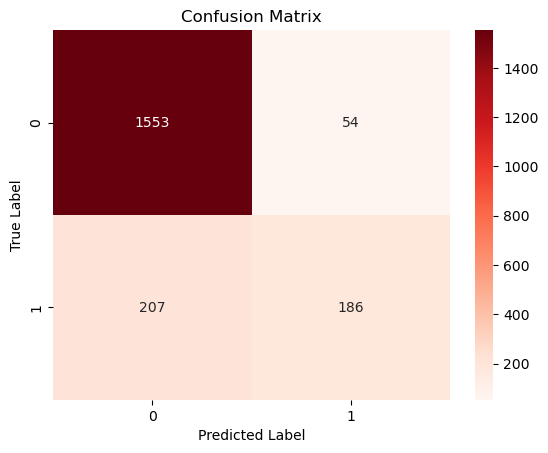

In [31]:
get_confusion_matrix(y_test, y_pred)

In [32]:
# SVM
svm = svm.SVC()
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)
get_accuracy_and_error(y_test, y_pred)

Accuracy: 80.35%
Error rate: 19.65%


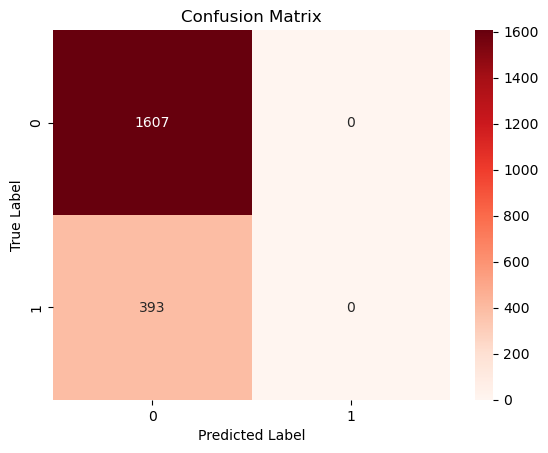

In [33]:
get_confusion_matrix(y_test, y_pred)

In [34]:
# XGBoost
xgb_model = XGBClassifier()
xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)
get_accuracy_and_error(y_test, y_pred)

Accuracy: 85.8%
Error rate: 14.2%


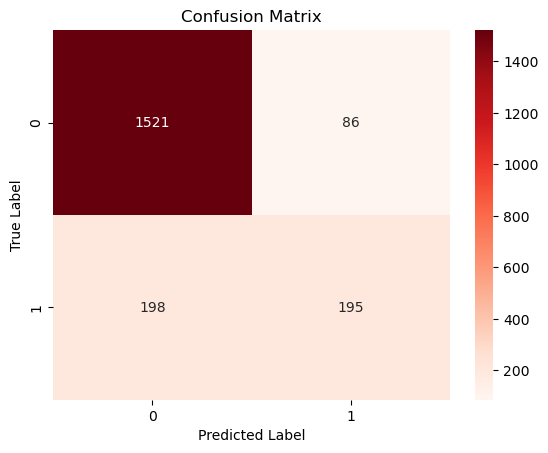

In [35]:
get_confusion_matrix(y_test, y_pred)